# Kinetic onset temperature of the Er$^{3+}$ Boltzmann thermometer

Feasibility check for the paper proposal: does `AndersonModelUnfolded`, parameterized from Anderson (2013) at room temperature and Suta (2025), reproduce Suta's onset temperature $T_{on}$ **without** using it as an input, and how does $T_{on}$ depend on excitation power?

Model state used here:
- $^2H_{11/2}$ (Er6h) 650 cm$^{-1}$ above $^4S_{3/2}$ (Er6s), from Suta's 77 K excitation spectra.
- 6s $\leftrightarrow$ 6h coupling with Suta's $k_{nr}(0) = 2.29\ \mu s^{-1}$ (`k_therm`), each rate carrying the degeneracy of its final level: $k_{down} = g_s k_{nr}(0)(1+n)^p$, $k_{up} = g_h k_{nr}(0)\, n^p$, $g_s = 4$, $g_h = 12$.
- $k_{r6h}/k_{r6s} = C = 5.52/3$ (Suta's LIR fit), split so that the model reduces to Anderson's $k_{r6}$ at $T_0 = 300$ K.
- Er–Er cross relaxation from level 6 (CR6) phonon-assisted: its 1600 cm$^{-1}$ mismatch is emitted as phonons, so it scales as $(1+n)^p$ from Anderson's value at $T_0$.
- A single effective phonon energy $\hbar\omega$ (`phonon_wavenumber`) for every multiphonon process, including the 6s $\leftrightarrow$ 6h coupling ($p = 650/\hbar\omega$).

In [1]:
import warnings

import numpy as np
from matplotlib import pyplot as plt
from pint import get_application_registry
from poincare import solvers

from upconversion_models import AndersonModel, AndersonModelUnfolded as M, cmap
from upconversion_models.jablonski_patch import EmissionTransform, Simulator, SteadyState

warnings.filterwarnings("ignore")
u = get_application_registry()

hc_k = 1.4388  # cm K
gap = 650  # cm-1, Er6h - Er6s
C = (M.k_r6h.default / M.k_r6s.default).to("").magnitude

# Suta 2025
suta_k1, suta_tau = 2430, 0.41e-3  # 1/s, s (4S3/2 at 77 K)
suta_Ton, suta_Ton_err = 100, 5  # K
suta_P = 5.5e-3  # W/cm2

sim = (
    Simulator(M())
    .with_transform(EmissionTransform("emission"), append=True)
    .with_solver(solvers.LSODA(rtol=1e-10, atol=1e-18))
)
steady = SteadyState()

### Observables

**$k_1$ at 77 K.** Suta measured the 4S3/2 decay after direct excitation into 2H11/2 (515 nm) and reports the intensity-weighted average $\langle\tau\rangle = 0.41$ ms, $k_1 = 1/\langle\tau\rangle$. We reproduce the experiment: no NIR pump, a small initial population in Er6h, and
$$\langle\tau\rangle = \frac{\int t\, I(t)\, dt}{\int I(t)\, dt}, \qquad I = \text{line\_rad6s1}$$

**$T_{on}$.** Since Er6s is fed only from Er6h, the model reduces to
$$\text{LIR} = C\left[\frac{g_h}{g_s} e^{-\Delta E/kT} + \frac{k_1(T,P)}{k_{21}(T)}\right]$$
$T_{on}$ is where the kinetic floor equals the Boltzmann term, i.e. LIR $= 2\times$ Boltzmann. This is the condition behind Suta's eq. 6, $g_h k_{nr}(0)\, n(T_{on})^p = k_1$.

In [2]:
def k1_direct(s, T, t_end=5e-3, n=20001):
    t = np.linspace(0, t_end, n)
    ds = s.with_values({M.T: T * u.K, M.Er6h: 1e-8}).solve(save_at=t * u.s).pint.dequantify()
    I = ds["line_rad6s1"].values
    return np.trapezoid(I, t) / np.trapezoid(t * I, t)


def boltzmann(T):
    return C * 12 / 4 * np.exp(-gap * hc_k / T)


def onset(s, P, Ts=np.arange(40, 310, 10.0)):
    ds = steady.sweep(
        s.with_values({M.energy_flux: P * u.W / u.cm**2}), variable=M.T, values=Ts * u.K
    )
    excess = (ds["line_rad6h1"] / ds["line_rad6s1"]).values / boltzmann(Ts) - 1
    # excess decreases with T; interpolate log(excess) = 0
    j = np.where(excess > 1)[0].max()
    x0, x1 = np.log(excess[j]), np.log(excess[j + 1])
    return Ts[j] + (Ts[j + 1] - Ts[j]) * (-x0) / (x1 - x0)

### Sweep of the effective phonon energy

$\hbar\omega$ enters $k_1(77\,K)$ mostly through the phonon-assisted CR6 ($p = 1600/\hbar\omega$, anchored at 300 K) and $T_{on}$ also through the 6s $\leftrightarrow$ 6h coupling ($p = 650/\hbar\omega$). At $T_0$ nothing depends on it.

Caveat: Suta extracted $k_{nr}(0)$ assuming $p = 2$ ($\hbar\omega_{eff} = 325$ cm$^{-1}$). For $\hbar\omega \neq 325$ cm$^{-1}$ the same number means a slightly different coupling.

In [3]:
phonons = np.array([200, 225, 250, 275, 298, 325, 350, 400, 450])
k1_77 = []
Ton = []
for w in phonons:
    s = sim.with_values({M.phonon_wavenumber: w / u.cm})
    k1_77.append(k1_direct(s, 77))
    Ton.append(onset(s, suta_P))
k1_77, Ton = np.array(k1_77), np.array(Ton)

for w, k, t in zip(phonons, k1_77, Ton):
    print(f"hw = {w:3d} cm-1   k1(77 K) = {k:6.0f} 1/s   <tau> = {1e3 / k:.3f} ms   T_on = {t:5.1f} K")

hw = 200 cm-1   k1(77 K) =   1566 1/s   <tau> = 0.639 ms   T_on =  94.7 K
hw = 225 cm-1   k1(77 K) =   1801 1/s   <tau> = 0.555 ms   T_on =  96.7 K
hw = 250 cm-1   k1(77 K) =   2157 1/s   <tau> = 0.464 ms   T_on =  98.8 K
hw = 275 cm-1   k1(77 K) =   2613 1/s   <tau> = 0.383 ms   T_on = 101.0 K
hw = 298 cm-1   k1(77 K) =   3092 1/s   <tau> = 0.323 ms   T_on = 103.1 K
hw = 325 cm-1   k1(77 K) =   3688 1/s   <tau> = 0.271 ms   T_on = 105.2 K
hw = 350 cm-1   k1(77 K) =   4240 1/s   <tau> = 0.236 ms   T_on = 106.9 K
hw = 400 cm-1   k1(77 K) =   5262 1/s   <tau> = 0.190 ms   T_on = 109.4 K
hw = 450 cm-1   k1(77 K) =   6110 1/s   <tau> = 0.164 ms   T_on = 111.4 K


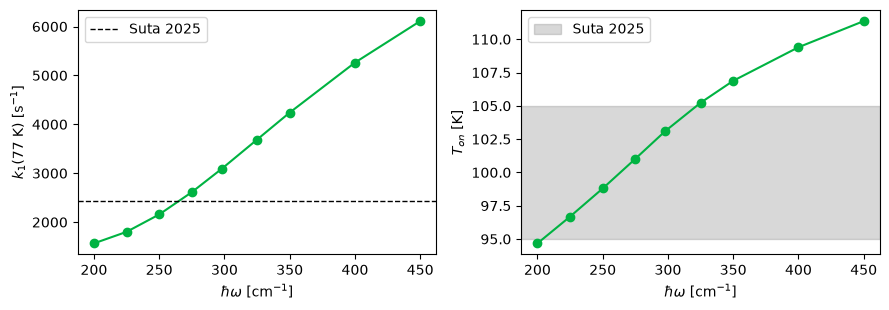

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3.2))

ax1.plot(phonons, k1_77, "o-", color=cmap["g"])
ax1.axhline(suta_k1, color="black", ls="--", lw=1, label="Suta 2025")
ax1.set_xlabel(r"$\hbar\omega$ [cm$^{-1}$]")
ax1.set_ylabel(r"$k_1$(77 K) [s$^{-1}$]")
ax1.legend()

ax2.plot(phonons, Ton, "o-", color=cmap["g"])
ax2.axhspan(suta_Ton - suta_Ton_err, suta_Ton + suta_Ton_err, color="gray", alpha=0.3, label="Suta 2025")
ax2.set_xlabel(r"$\hbar\omega$ [cm$^{-1}$]")
ax2.set_ylabel(r"$T_{on}$ [K]")
ax2.legend()

fig.tight_layout()
plt.show()

### Onset temperature vs excitation power

Above Suta's power density the ETU out of 4S3/2 (6s $\to$ 9) adds to $k_1$, so $T_{on}$ should rise. Compared for the $\hbar\omega$ that best matches Suta's $k_1$ and for the current default (298 cm$^{-1}$).

best hw = 275 cm-1
P =   0.0055 W/cm2   T_on(hw=275) = 101.0 K   T_on(hw=298) = 103.1 K
P =      0.1 W/cm2   T_on(hw=275) = 101.4 K   T_on(hw=298) = 103.5 K
P =        1 W/cm2   T_on(hw=275) = 104.5 K   T_on(hw=298) = 106.1 K
P =        3 W/cm2   T_on(hw=275) = 108.4 K   T_on(hw=298) = 109.5 K
P =       10 W/cm2   T_on(hw=275) = 114.9 K   T_on(hw=298) = 115.7 K
P =       30 W/cm2   T_on(hw=275) = 122.1 K   T_on(hw=298) = 122.5 K
P =      100 W/cm2   T_on(hw=275) = 131.4 K   T_on(hw=298) = 131.6 K
P =      300 W/cm2   T_on(hw=275) = 141.3 K   T_on(hw=298) = 141.4 K


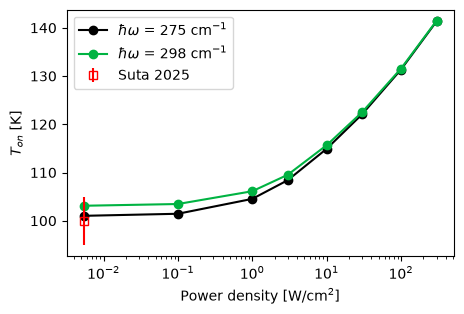

In [5]:
best = phonons[np.argmin(np.abs(np.log(k1_77 / suta_k1)))]
powers = np.array([suta_P, 0.1, 1, 3, 10, 30, 100, 300])

Ton_P = {}
for w in sorted({best, 298}):
    s = sim.with_values({M.phonon_wavenumber: w / u.cm})
    Ton_P[w] = np.array([onset(s, P) for P in powers])

print(f"best hw = {best} cm-1")
for i, P in enumerate(powers):
    print(f"P = {P:8.4g} W/cm2   " + "   ".join(f"T_on(hw={w}) = {Ton_P[w][i]:5.1f} K" for w in Ton_P))

fig, ax = plt.subplots(figsize=(5, 3.2))
for w, color in zip(Ton_P, ["black", cmap["g"]]):
    ax.semilogx(powers, Ton_P[w], "o-", color=color, label=rf"$\hbar\omega$ = {w} cm$^{{-1}}$")
ax.errorbar([suta_P], [suta_Ton], yerr=[suta_Ton_err], fmt="s", color=cmap["r"], mfc="none", label="Suta 2025")
ax.set_xlabel(r"Power density [W/cm$^2$]")
ax.set_ylabel(r"$T_{on}$ [K]")
ax.legend()
plt.show()

### Consistency with Anderson at $T_0$

At 300 K every temperature factor is 1, so the unfolded model, with the 6s and 6h lines recombined, should match `AndersonModel`.

In [6]:
anderson = (
    Simulator(AndersonModel())
    .with_transform(EmissionTransform("emission"), append=True)
    .with_solver(solvers.LSODA(rtol=1e-10, atol=1e-18))
)


def value(ds, key):
    v = ds[key].item()
    return getattr(v, "magnitude", v)


for P in [1, 5, 50]:
    a = steady.solve(anderson.with_values({AndersonModel.energy_flux: P * u.W / u.cm**2}))
    m = steady.solve(sim.with_values({M.energy_flux: P * u.W / u.cm**2}))
    green = (value(m, "line_rad6s1") + value(m, "line_rad6h1")) / value(a, "line_rad61")
    red = value(m, "line_rad51") / value(a, "line_rad51")
    blue = value(m, "line_rad81") / value(a, "line_rad81")
    print(f"P = {P:3d} W/cm2   unfolded / Anderson:  green {green:.4f}   red {red:.4f}   blue {blue:.4f}")

P =   1 W/cm2   unfolded / Anderson:  green 0.9990   red 1.0130   blue 0.9934


P =   5 W/cm2   unfolded / Anderson:  green 0.9991   red 1.0154   blue 0.9948
P =  50 W/cm2   unfolded / Anderson:  green 0.9994   red 1.0177   blue 0.9969


### Summary

- Suta's $k_1 = 2430$ s$^{-1}$ at 77 K falls between $\hbar\omega = 250$ and $275$ cm$^{-1}$ (≈ 265 cm$^{-1}$ by interpolation). With 298 cm$^{-1}$ (Suyver's lowest dominant Raman mode) the model gives $\langle\tau\rangle = 0.32$ ms vs 0.41 ms measured. Without phonon-assisted CR6 it was 0.11 ms.
- $T_{on}$ at Suta's power is weakly sensitive to $\hbar\omega$: 95–111 K over 200–450 cm$^{-1}$, and 101 K at 275 cm$^{-1}$, inside Suta's $100 \pm 5$ K. Neither $T_{on}$ nor $k_1$ was used as input.
- $T_{on}$ rises with power, from ≈ 101 K at 5.5 mW/cm$^2$ to ≈ 141 K at 300 W/cm$^2$, independently of $\hbar\omega$ above ~10 W/cm$^2$: there the ETU out of 4S3/2 dominates $k_1$.
- At $T_0$ the model matches Anderson within 0.1 % in green, but red is 1.3–1.8 % high and blue 0.3–0.7 % low. Still to be traced (suspect: detailed-balance upward partners such as 8 → 9).